In [25]:
import pandas as pd
import h5py as h5
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np

In [26]:
csv_results = pd.read_csv('../wandb_csv/data_scarcity_results.csv')

In [27]:
csv_results.columns

Index(['Name', 'test/f1', 'data.percentage', 'data.mta', 'Group', 'State',
       'Notes', 'User', 'Tags', 'Created',
       ...
       'train/loss', 'train/loss_lc', 'val/f1', 'val/f1_lc', 'val/loss',
       'val/loss_lc', 'test/f1_lc', 'test/loss', 'test/loss_lc',
       'trainer/global_step'],
      dtype='object', length=155)

In [28]:
selected_columns = ['Group','test/f1','data.percentage']

In [29]:
csv_results_filtered = csv_results[selected_columns]    

In [30]:
csv_results_filtered['data.percentage'].unique()

array([ nan, 1.  , 0.01, 0.1 , 0.25, 0.5 , 2.  ])

In [31]:
# Replace nan with -1 and 2 with 1
csv_results_filtered = csv_results_filtered.copy()
csv_results_filtered['data.percentage'] = csv_results_filtered['data.percentage'].fillna(-1)
csv_results_filtered['data.percentage'] = csv_results_filtered['data.percentage'].replace(2, 1)

In [32]:
csv_results_filtered['data.percentage'].unique()

array([-1.  ,  1.  ,  0.01,  0.1 ,  0.25,  0.5 ])

In [33]:
#remove simclr and winwdowed
selected_groups = ['DiViT-Large-LinearClassification', 'DiViT-Large-VICReg',
       'DiViT_Large', 'DiViT-LinearClassification', 'DiViT_VICReg',
       'DiViT','DiT-VICReg-LinearClassification', 'DiT_VICReg', 'DiT', 'ATAT']
#
csv_results_filtered = csv_results_filtered[csv_results_filtered['Group'].isin(selected_groups)]

In [37]:
# Replace 'Large' with 'L', '_' with '-', 'VICReg' with 'PT', and remove 'LinearClassification'
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('Large', 'L')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('_', '-')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('VICReg', 'PT')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('-LinearClassification', '')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('LinearClassification', '')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('DiViT-L', 'DiffViT-L')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('DiT', 'DiffT')
csv_results_filtered['Group'] = csv_results_filtered['Group'].str.replace('DiViT', 'DiffViT')

In [38]:
#given selected groups, filter csv_results_filtered
#group by data.percentage and Group, then calculate mean and std of test/f1
grouped = csv_results_filtered.groupby(['data.percentage', 'Group'])['test/f1'].agg(['mean', 'std']).reset_index()

✓ Plot saved to f1_score_linear_left_finetune_ordered.pdf


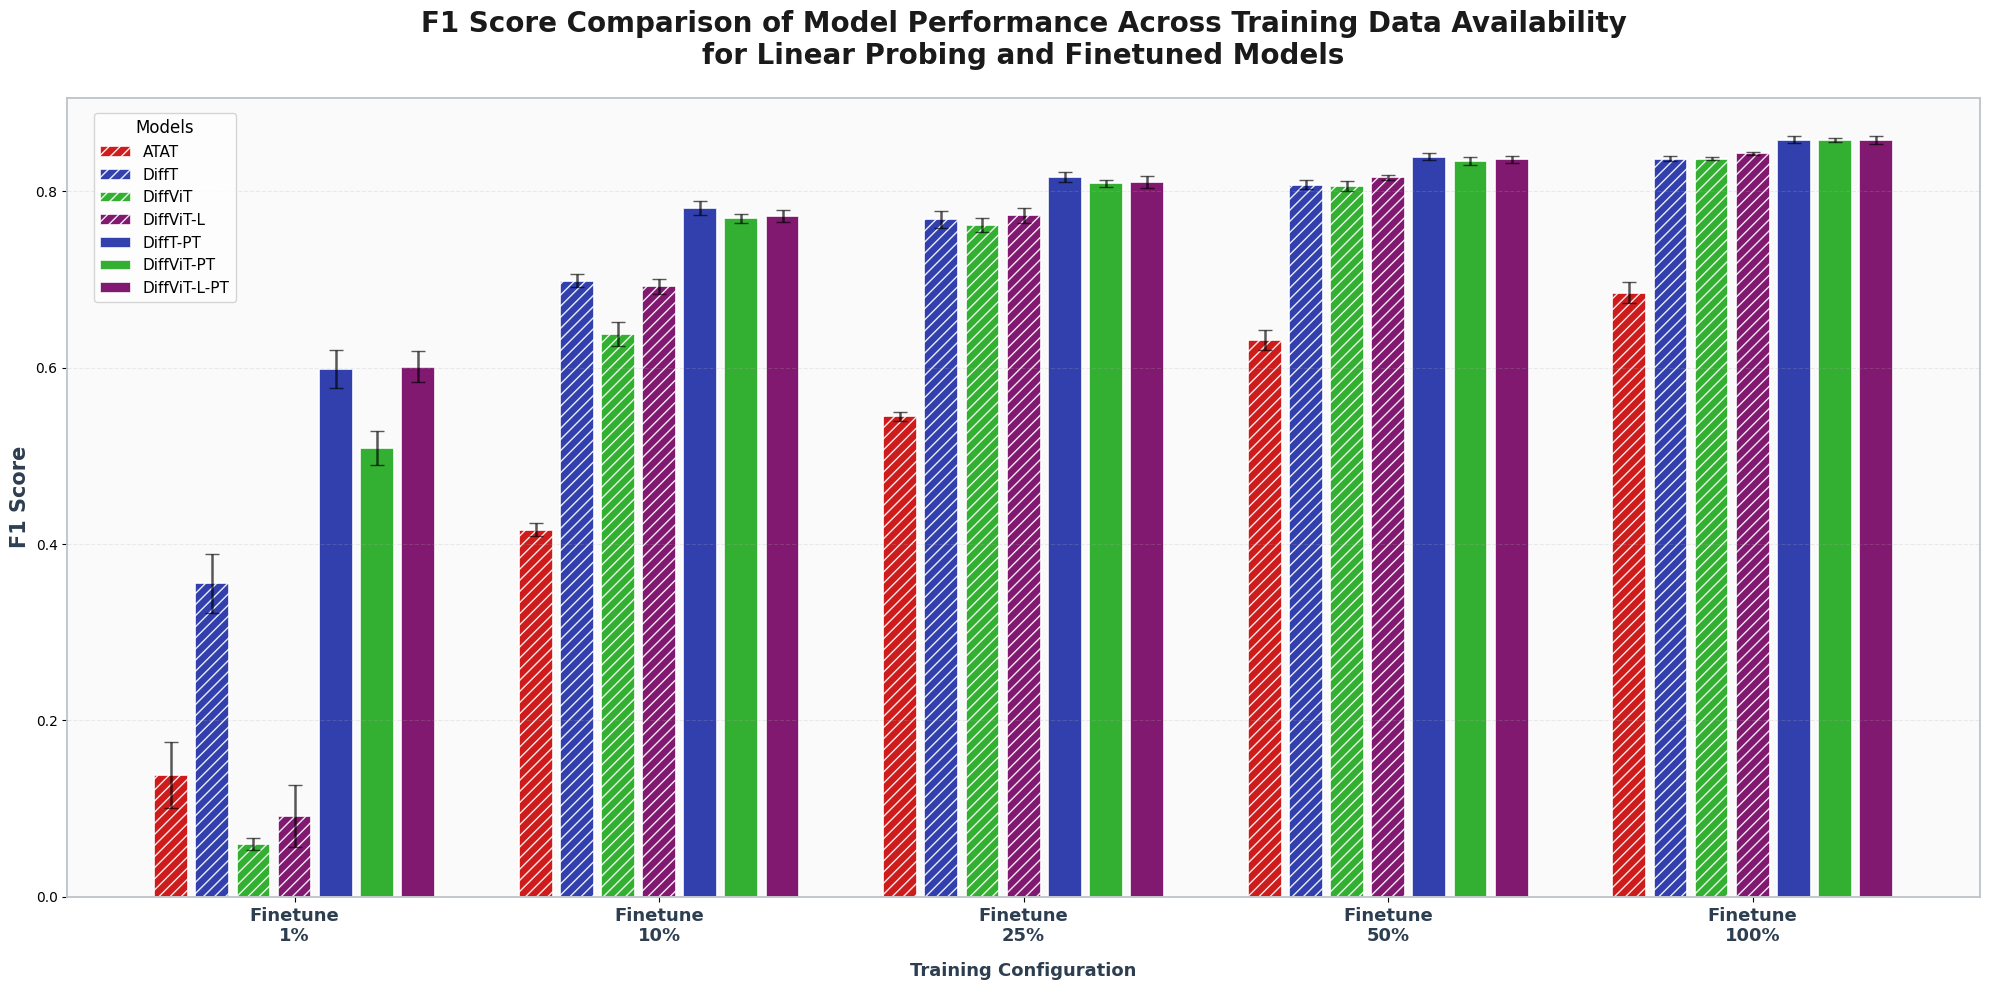

✓ Table saved to f1_score_linear_left_finetune_ordered.csv


In [39]:
# Plot F1 score comparison with linear classification on the left and ordered model bars
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Split grouped statistics into fine-tuning (percentage >= 0) and linear probe (percentage == -1)
fine_tune_df = grouped[grouped['data.percentage'] >= 0].copy()
linear_df = grouped[grouped['data.percentage'] == -1].copy()

if fine_tune_df.empty and linear_df.empty:
    raise ValueError("No data available to plot. Please verify the input CSV.")

# Desired ordering: base models first, then specified pretrained variants
available_groups = list(csv_results_filtered['Group'].unique())
desired_order = ['ATAT', 'DiffT', 'DiffViT', 'DiffViT-L', 'DiffT-PT', 'DiffViT-PT', 'DiffViT-L-PT']
ordered_models = [model for model in desired_order if model in available_groups]

# Include any remaining groups (to avoid data loss)
remaining_models = [model for model in sorted(available_groups) if model not in ordered_models]
ordered_models.extend(remaining_models)

def base_model_name(model: str) -> str:
    return model.replace('-PT', '')

# Shared color palette across model families (bright tones)
base_palette = ["#CA0404", "#1C2CA6", "#1DA81B", "#730060", '#A66DD3', '#38B6FF', '#FF8E72']
base_order = []
for model in ordered_models:
    base_name = base_model_name(model)
    if base_name not in base_order:
        base_order.append(base_name)
base_colors = {base: base_palette[idx % len(base_palette)] for idx, base in enumerate(base_order)}
model_colors = {model: base_colors[base_model_name(model)] for model in ordered_models}
model_hatches = {model: '' if model.endswith('-PT') else '///' for model in ordered_models}

# Categories: fine-tuning first (ascending percentages), linear probing last
fine_percentages = sorted(fine_tune_df['data.percentage'].unique()) if not fine_tune_df.empty else []
category_info = [('Finetune', pct) for pct in fine_percentages]
include_linear = False
if include_linear:
    category_info.append(('Linear probing', -1))

def format_percentage(value: float) -> str:
    if value == -1:
        return '100%'
    return f"{value * 100:.0f}%"

categories = [f"{label}\n{format_percentage(val)}" for label, val in category_info]
n_categories = len(categories)

# Base x positions with compact spacing before the linear probing section
x_base = np.arange(n_categories, dtype=float)
if include_linear and n_categories > 1:
    x_base[-1] += 0.20  # further tighten the dedicated space for linear probing

# Bar width and spacing tuned for clarity
bar_width = max(0.65 / max(len(ordered_models), 1), 0.08)
bar_spacing = 0.02

fig, ax = plt.subplots(figsize=(20, 10))
data_records = []

# Plot bars for each model in the desired order
for idx, model in enumerate(ordered_models):
    means = []
    stds = []

    for label, value in category_info:
        if value == -1:
            raw_rows = csv_results_filtered[(csv_results_filtered['Group'] == model) &
                                            (csv_results_filtered['data.percentage'] == -1)]
        else:
            raw_rows = csv_results_filtered[(csv_results_filtered['Group'] == model) &
                                            (csv_results_filtered['data.percentage'] == value)]

        if not raw_rows.empty:
            mean_val = float(raw_rows['test/f1'].mean())
            std_val = float(raw_rows['test/f1'].std(ddof=1))
            if np.isnan(std_val):
                std_val = 0.0
        else:
            mean_val = np.nan
            std_val = 0.0

        means.append(mean_val)
        stds.append(std_val)
        data_records.append({
            'model': model,
            'category_label': label,
            'data_percentage': 1.0 if value == -1 else float(value),
            'display_percentage': format_percentage(value),
            'mean_f1': mean_val,
            'std_f1': std_val
        })

    offset = (idx - (len(ordered_models) - 1) / 2) * (bar_width + bar_spacing)
    positions = x_base + offset

    bars = ax.bar(positions, means, bar_width, yerr=stds,
                  label=model if idx == 0 else None,
                  color=model_colors[model], alpha=0.9,
                  edgecolor='white', linewidth=1.3,
                  error_kw={'elinewidth': 1.8, 'capsize': 5, 'alpha': 0.65})
    for bar in bars:
        bar.set_hatch(model_hatches[model])

# Aesthetics
ax.set_title('F1 Score Comparison of Model Performance Across Training Data Availability\nfor Linear Probing and Finetuned Models',
             fontsize=20, fontweight='bold', pad=24, color='#1A1A1A')
ax.set_xticks(x_base)
ax.set_xticklabels(categories, fontsize=13, fontweight='600', color='#2C3E50')
ax.set_ylabel('F1 Score', fontsize=15, fontweight='bold', color='#2C3E50')
ax.set_xlabel('Training Configuration', fontsize=13, fontweight='bold', color='#2C3E50', labelpad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.22)
ax.set_facecolor('#FAFAFA')

# Vertical separator before linear probing
if include_linear and n_categories > 1:
    separator_x = (x_base[-2] + x_base[-1]) / 2
    ax.axvline(separator_x, color='#95A5A6', linestyle='--', linewidth=2, alpha=0.55)

# Custom legend showing all models once
legend_handles = [
    Patch(facecolor=model_colors[m], edgecolor='white', linewidth=1.3, hatch=model_hatches[m], alpha=0.9)
    for m in ordered_models
]
ax.legend(legend_handles, ordered_models, loc='upper left', bbox_to_anchor=(0.01, 0.99),
          frameon=True, fancybox=True, shadow=False, fontsize=11,
          title='Models', title_fontsize=12)

# Adjust spines
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(1.3)

plt.tight_layout()
output_path = 'f1_score_linear_left_finetune_ordered.pdf'
fig.savefig(output_path, dpi=1200, bbox_inches='tight', facecolor='white')
print(f"✓ Plot saved to {output_path}")
plt.show()

results_df = pd.DataFrame(data_records)
csv_path = 'f1_score_linear_left_finetune_ordered.csv'
results_df.to_csv(csv_path, index=False)
print(f"✓ Table saved to {csv_path}")